# Applied Linear Algebra - Real Algorithms

Now you know the basics. Let's use them for **real algorithms**.

## What you'll learn:

| Algorithm | Linear Algebra Concept | Used For |
|-----------|----------------------|----------|
| PCA | Eigenvalues/Eigenvectors | Reduce dimensions |
| Least Squares | Matrix Inverse | Regression/fitting |
| Cosine Similarity | Dot Product | Compare documents/vectors |
| Image Compression | SVD | Compress data |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

---
## 1. PCA (Principal Component Analysis)

### Problem: You have 100 features but only 5 contain real information.

### PCA finds the **most important directions** in your data.

### How it works:
1. Center the data (subtract mean)
2. Compute covariance matrix
3. Find eigenvalues/eigenvectors of covariance matrix
4. Sort by eigenvalue (biggest = most important)
5. Project data onto top eigenvectors

### The eigenvectors = principal components = directions of maximum variance
### The eigenvalues = how much variance each direction explains

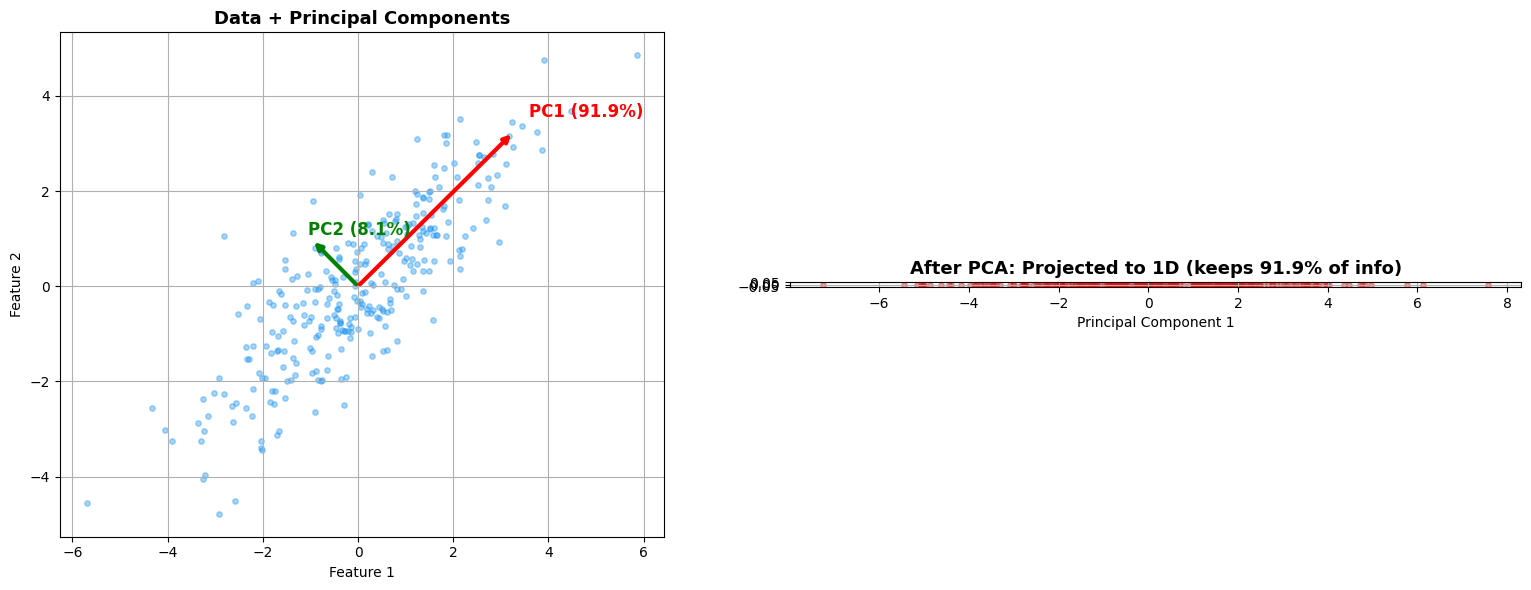

PC1 explains: 91.9% of variance
PC2 explains: 8.1% of variance

With just PC1, we keep 91.9% of information using 1 number instead of 2!
This is dimensionality reduction.


In [2]:
np.random.seed(42)

mean = [3, 5]
cov = [[3, 2.5], [2.5, 3]]
data = np.random.multivariate_normal(mean, cov, 300)

centered = data - data.mean(axis=0)
cov_matrix = np.cov(centered.T)

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

total_var = eigenvalues.sum()
explained = eigenvalues / total_var * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.scatter(centered[:, 0], centered[:, 1], alpha=0.4, s=15, c='#2196F3')
for i, (color, label) in enumerate(zip(['red', 'green'], ['PC1', 'PC2'])):
    v = eigenvectors[:, i] * np.sqrt(eigenvalues[i]) * 2
    ax.annotate('', xy=v, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=color, lw=3))
    ax.text(v[0]*1.1, v[1]*1.1, f'{label} ({explained[i]:.1f}%)',
            fontsize=12, color=color, fontweight='bold')
ax.set_title('Data + Principal Components', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_aspect('equal')

ax = axes[1]
projected_1d = centered @ eigenvectors[:, 0:1]
ax.scatter(projected_1d, np.zeros_like(projected_1d), alpha=0.4, s=15, c='red')
ax.set_title('After PCA: Projected to 1D (keeps {:.1f}% of info)'.format(explained[0]),
             fontsize=13, fontweight='bold')
ax.set_xlabel('Principal Component 1')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"PC1 explains: {explained[0]:.1f}% of variance")
print(f"PC2 explains: {explained[1]:.1f}% of variance")
print(f"\nWith just PC1, we keep {explained[0]:.1f}% of information using 1 number instead of 2!")
print("This is dimensionality reduction.")

---
## 2. Least Squares Regression

### Problem: Find the best line through data points.

### The math: `y = X @ w` → find `w` that minimizes `||y - X @ w||^2`

### Solution (normal equation):
```
w = (X^T X)^(-1) X^T y
```

This is PURE linear algebra! Matrix transpose, inverse, and multiplication.

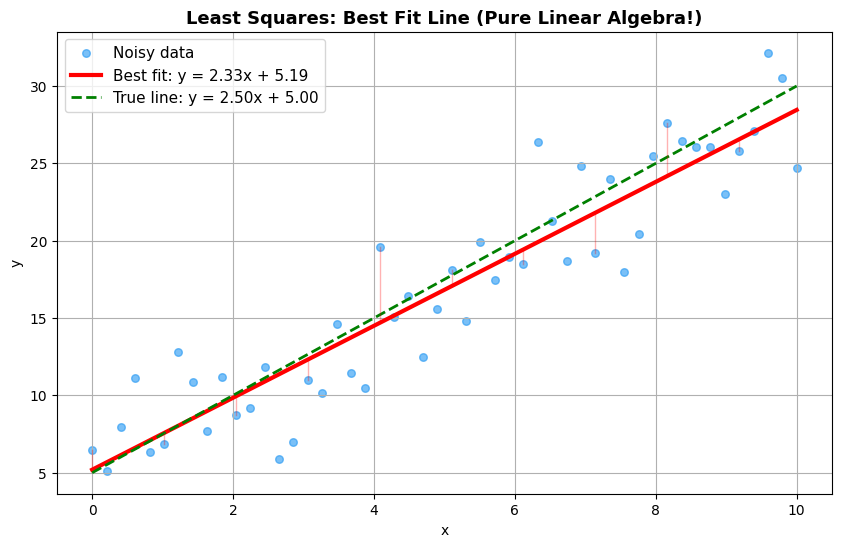

Found: intercept=5.19, slope=2.33
True:  intercept=5.00, slope=2.50

Formula: w = (X^T X)^(-1) X^T y
This is just matrix operations! No calculus needed.


In [3]:
np.random.seed(42)

x = np.linspace(0, 10, 50)
y_true = 2.5 * x + 5
y_noisy = y_true + np.random.normal(0, 3, len(x))

X = np.column_stack([np.ones_like(x), x])

w = np.linalg.inv(X.T @ X) @ X.T @ y_noisy

y_pred = X @ w

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x, y_noisy, alpha=0.6, s=30, c='#2196F3', label='Noisy data')
ax.plot(x, y_pred, 'r-', linewidth=3, label=f'Best fit: y = {w[1]:.2f}x + {w[0]:.2f}')
ax.plot(x, y_true, 'g--', linewidth=2, label=f'True line: y = 2.50x + 5.00')

for xi, yi, yp in zip(x[::5], y_noisy[::5], y_pred[::5]):
    ax.plot([xi, xi], [yi, yp], 'r-', alpha=0.3, linewidth=1)

ax.set_title('Least Squares: Best Fit Line (Pure Linear Algebra!)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.show()

print(f"Found: intercept={w[0]:.2f}, slope={w[1]:.2f}")
print(f"True:  intercept=5.00, slope=2.50")
print(f"\nFormula: w = (X^T X)^(-1) X^T y")
print("This is just matrix operations! No calculus needed.")

---
## 3. Cosine Similarity (Document Comparison)

### Problem: How similar are two documents?

### Solution: Represent each as a vector, measure the **angle** between them.

```
cosine_similarity = (a . b) / (|a| * |b|)
```

- **1** = identical direction (same topic)
- **0** = perpendicular (unrelated)
- **-1** = opposite (very different)

### Why cosine instead of dot product?
Cosine normalizes by vector length → immune to document length.
A long document about cats and a short one about cats should still be similar.

In [4]:
docs = {
    'Cat doc':    np.array([5, 0, 3, 0, 2, 0]),
    'Kitten doc': np.array([3, 0, 1, 0, 1, 0]),
    'Dog doc':    np.array([0, 4, 0, 5, 0, 2]),
    'Fish doc':   np.array([0, 0, 0, 0, 0, 6]),
}
vocab = ['cat', 'dog', 'kitten', 'puppy', 'meow', 'swim']

def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

names = list(docs.keys())
vectors = list(docs.values())

print("Vocabulary:", vocab)
print("\n=== Cosine Similarity Matrix ===")
print(f"{'':>14}", end='')
for name in names:
    print(f"{name:>14}", end='')
print()

for i, name_i in enumerate(names):
    print(f"{name_i:>14}", end='')
    for j, name_j in enumerate(names):
        sim = cosine_sim(vectors[i], vectors[j])
        print(f"{sim:>14.3f}", end='')
    print()

print(f"\nCat doc and Kitten doc are very similar: {cosine_sim(vectors[0], vectors[1]):.3f}")
print(f"Cat doc and Dog doc are unrelated:       {cosine_sim(vectors[0], vectors[2]):.3f}")
print(f"Cat doc and Fish doc are unrelated:      {cosine_sim(vectors[0], vectors[3]):.3f}")
print("\nThis is how search engines find similar documents!")

Vocabulary: ['cat', 'dog', 'kitten', 'puppy', 'meow', 'swim']

=== Cosine Similarity Matrix ===
                     Cat doc    Kitten doc       Dog doc      Fish doc
       Cat doc         1.000         0.978         0.000         0.000
    Kitten doc         0.978         1.000         0.000         0.000
       Dog doc         0.000         0.000         1.000         0.298
      Fish doc         0.000         0.000         0.298         1.000

Cat doc and Kitten doc are very similar: 0.978
Cat doc and Dog doc are unrelated:       0.000
Cat doc and Fish doc are unrelated:      0.000

This is how search engines find similar documents!


---
## 4. SVD for Image Compression

### SVD decomposes a matrix into 3 pieces: `A = U @ S @ Vt`

### Compression trick:
Keep only the top-k singular values. The rest are small and don't matter much.

```
Full:  A = U(all) @ S(all) @ Vt(all)     → exact reconstruction
Compressed: A ≈ U(:k) @ S(:k) @ Vt(:k)   → k components
```

### Why it works:
Singular values are sorted largest to smallest.
The biggest ones capture the most important patterns.
The small ones are noise/detail you can drop.

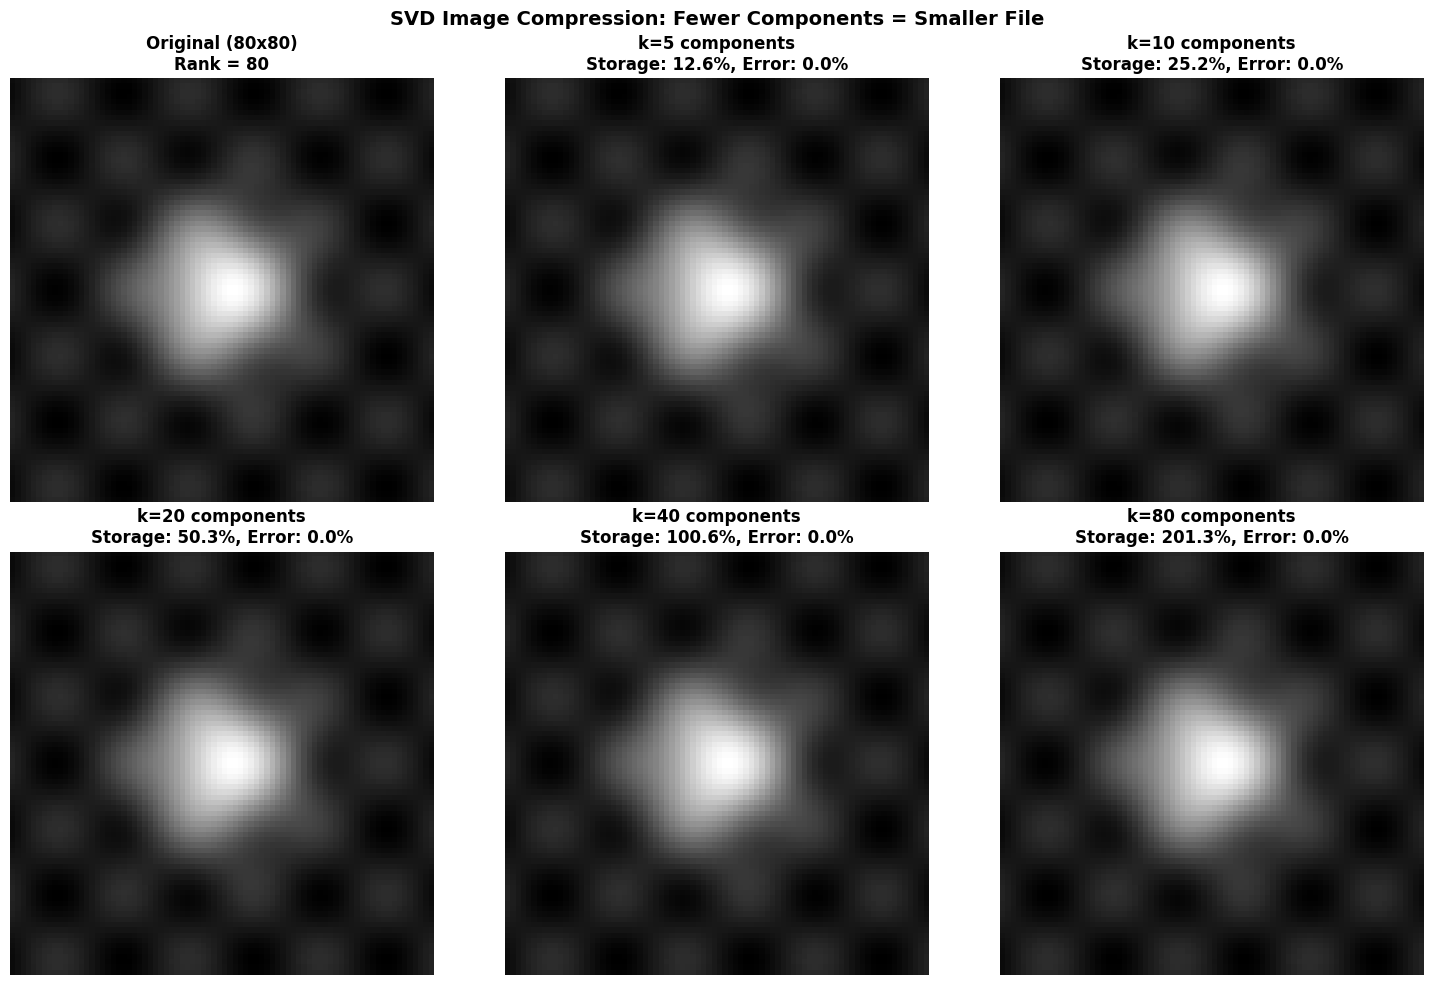

With k=20 out of 80 components, you keep the essence of the image
while storing only ~50% of the original data.
This is how JPEG compression works (similar principle)!


In [5]:
np.random.seed(42)

x = np.linspace(-2, 2, 80)
y = np.linspace(-2, 2, 80)
X, Y = np.meshgrid(x, y)

image = np.exp(-(X**2 + Y**2) / 0.5)
image += 0.1 * np.sin(5*X) * np.cos(5*Y)
image = (image - image.min()) / (image.max() - image.min())

U, S, Vt = np.linalg.svd(image, full_matrices=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title(f'Original ({image.shape[0]}x{image.shape[1]})\nRank = {len(S)}', fontweight='bold')

k_values = [5, 10, 20, 40, 80]
positions = [(0,1), (0,2), (1,0), (1,1), (1,2)]

for k, (r, c) in zip(k_values, positions):
    compressed = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
    compressed = np.clip(compressed, 0, 1)
    storage_pct = k * (image.shape[0] + image.shape[1] + 1) / (image.shape[0] * image.shape[1]) * 100
    error = np.linalg.norm(image - compressed) / np.linalg.norm(image) * 100
    axes[r, c].imshow(compressed, cmap='gray')
    axes[r, c].set_title(f'k={k} components\nStorage: {storage_pct:.1f}%, Error: {error:.1f}%', fontweight='bold')

for ax in axes.flat:
    ax.axis('off')

plt.suptitle('SVD Image Compression: Fewer Components = Smaller File', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("With k=20 out of 80 components, you keep the essence of the image")
print("while storing only ~50% of the original data.")
print("This is how JPEG compression works (similar principle)!")

---
## 5. Summary

| Algorithm | LA Concept | One-line Summary |
|-----------|-----------|------------------|
| PCA | Eigenvalues of covariance | Find most important directions |
| Least Squares | Matrix inverse | Best fit line via normal equation |
| Cosine Similarity | Dot product + norm | Compare documents by angle |
| SVD Compression | Singular values | Keep big components, drop small |

### The pattern: ALL of these are just matrix operations!

```
PCA           = eigen(covariance_matrix)
Least Squares = (X^T X)^(-1) X^T y
Cosine Sim    = dot(a,b) / (norm(a) * norm(b))
SVD           = U @ diag(S) @ Vt
```

### Next: Optimization (`07_optimization_basics.ipynb`)